### Advanced topics in explainable AI

COnsistency
- Assesses stability of explanations when model trained on different subsets
- Low consistency -> no robust explanations


### Cosine similarity to measure consistency

- -1 Opposite explanations
-  0 No consistency explanations 
-  1 Highly consistent explanations 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
admission = pd.read_csv("admission_data.csv")
admission.head(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit,Accept
0,337,118,4,4.5,4.5,9.65,0.92,1
1,324,107,4,4.0,4.5,8.87,0.76,1
2,316,104,3,3.0,3.5,8.00,0.72,1
3,322,110,3,3.5,2.5,8.67,0.80,1
4,314,103,2,2.0,3.0,8.21,0.65,0
5,330,115,5,4.5,3.0,9.34,0.90,1
6,321,109,3,3.0,4.0,8.20,0.75,1
7,308,101,2,3.0,4.0,7.90,0.68,0
8,302,102,1,2.0,1.5,8.00,0.50,0
9,323,108,3,3.5,3.0,8.60,0.45,0


In [5]:
admission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                498 non-null    float64
 5   CGPA               500 non-null    float64
 6   Chance of Admit    500 non-null    float64
 7   Accept             500 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


In [3]:
from sqlalchemy import column
X = admission.drop(columns=["Accept"], axis=0)
y = admission["Accept"]

In [8]:
X1 = X[:, 0:250]

InvalidIndexError: (slice(None, None, None), slice(0, 250, None))

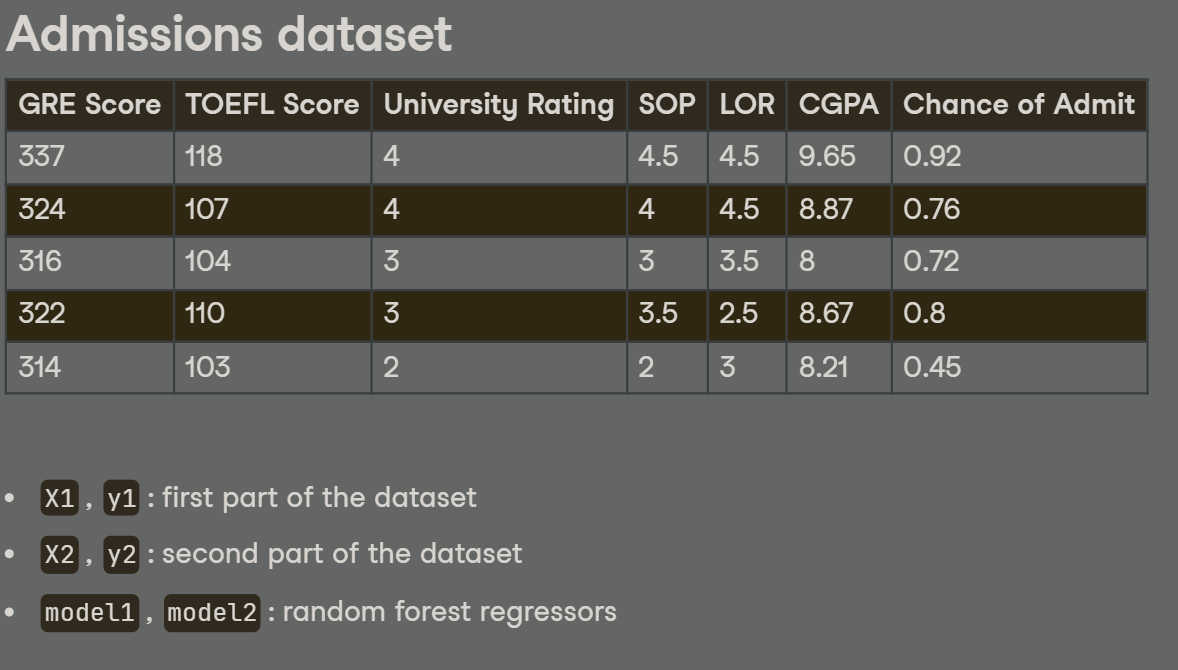

Computing consistency

In [ ]:
from Foundations of Explainable AI import feature_importances
from sklearn.metrics.pairwise import cosine_similarity
import shap
explainer1 = shap.TreeExplainer(model1)
explainer2 = shap.TreeExplainer(model2)

shap_value1 = explainer1.shap_values(X1)
shap_value2 = explainer2.shap_values(X2)

feature_importance1 = np.mean(np.abs(shap_value1), axis=0)
feature_importance2 = np.mean(np.abs(shap_value2), axis=0)

consistency = cosine_similarity([feature_importance1], [feature_importance2])
print("Consistency between SHAP values:", consistency)

### Faithfulness
- Evaluates if important features influence model's predictions
- Low faithfullness -> misleads trust in model reasoning
- Useful in sensitive applications

Computing faithfulness

In [ ]:
X_instance = X_test.iloc[[0]]
original_prediction = model.predict_proba(X_instance)[0, 1]
print(f"Original Prediction: {original_prediction}")


In [ ]:
X_instance["GRE Score"] = 310

new_prediction = model.predict_proba(X_instance)[0, 1]
print(f"Prediction after preturbing {importance_feature}: {new_prediction}")

faithfulness_score = np.abs(original_prediction - new_prediction)
print(f"Local Faithfulness Score: {faithfulness_score}")

### Exercise:

Evaluating SHAP explanation consistency

In [ ]:
# Calculate SHAP values and feature importance for model1
explainer1 = shap.TreeExplainer(model1)
shap_values1 = explainer1.shap_values(X1)
feature_importance1 = np.mean(np.abs(shap_values1), axis=0)

# Calculate SHAP values and feature importance for model2
explainer2 = shap.TreeExplainer(model2)
shap_values2 = explainer2.shap_values(X2)
feature_importance2 =np.mean(np.abs(shap_values2), axis=0)

# Consistency calculation
consistency = cosine_similarity([feature_importance1], [feature_importance2])
print("Consistency between SHAP values:", consistency)